In [1]:
# Run garbage collection
import gc
gc.collect()

0

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import logging
import wfdb
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler

In [3]:
def normalize_data_z_score(data: np.ndarray) -> np.ndarray:
    num_samples, sample_length, num_channels = data.shape
    data_reshaped = data.reshape(-1, num_channels)
    scaler = StandardScaler()
    data_normalized = scaler.fit_transform(data_reshaped)
    return data_normalized.reshape(num_samples, sample_length, num_channels)

In [4]:
path_load = './data_source_sub'


##train
X_train = np.load(os.path.join(path_load, 'Y_train.npy'))
X_train = normalize_data_z_score(X_train)

y_train = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
y_train = y_train.drop(columns=['ecg_id'])
y_train = y_train.to_numpy(dtype=np.float32)

z_train = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
z_train = z_train.drop(columns=['ecg_id'])
z_train = z_train.to_numpy(dtype=np.float32)

##test
X_test = np.load(os.path.join(path_load, 'Y_test.npy'))
X_test = normalize_data_z_score(X_test)

y_test = pd.read_csv(os.path.join(path_load, 'Z_test.csv'))
y_test = y_test.drop(columns=['ecg_id'])
y_test = y_test.to_numpy(dtype=np.float32)

z_test = pd.read_csv(os.path.join(path_load, 'T_test.csv'))
z_test = z_test.drop(columns=['ecg_id'])
z_test = z_test.to_numpy(dtype=np.float32)

##validation
X_val = np.load(os.path.join(path_load, 'Y_valid.npy'))
X_val = normalize_data_z_score(X_val)

y_val = pd.read_csv(os.path.join(path_load, 'Z_valid.csv'))
y_val = y_val.drop(columns=['ecg_id'])
y_val = y_val.to_numpy(dtype=np.float32)

z_val = pd.read_csv(os.path.join(path_load, 'T_valid.csv'))
z_val = z_val.drop(columns=['ecg_id'])
z_val = z_val.to_numpy(dtype=np.float32)

table = [
    ["X_train", X_train.shape],
    ["y_train", y_train.shape],
    ["z_train", z_train.shape],
    ["X_test", X_test.shape],
    ["y_test", y_test.shape],
    ["z_test", z_test.shape],
    ["X_val", X_val.shape],
    ["y_val", y_val.shape],
    ["z_val", z_val.shape],
]

print(tabulate(table, headers=["Dataset", "Shape"], tablefmt="grid"))

+-----------+-------------------+
| Dataset   | Shape             |
+===========+===================+
| X_train   | (17418, 1000, 12) |
+-----------+-------------------+
| y_train   | (17418, 5)        |
+-----------+-------------------+
| z_train   | (17418, 23)       |
+-----------+-------------------+
| X_test    | (2198, 1000, 12)  |
+-----------+-------------------+
| y_test    | (2198, 5)         |
+-----------+-------------------+
| z_test    | (2198, 23)        |
+-----------+-------------------+
| X_val     | (2183, 1000, 12)  |
+-----------+-------------------+
| y_val     | (2183, 5)         |
+-----------+-------------------+
| z_val     | (2183, 23)        |
+-----------+-------------------+


In [5]:
classes_label = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
#print(classes_label.columns[1:])
label_map = {label: i for i, label in enumerate(classes_label.columns[1:])}
print(label_map)

subclasses_label = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
#print(subclasses_label.columns[1:])
label_map_sub = {label: i for i, label in enumerate(subclasses_label.columns[1:])}
print(label_map_sub)

{'NORM': 0, 'CD': 1, 'HYP': 2, 'MI': 3, 'STTC': 4}
{'NORM': 0, 'LAFB/LPFB': 1, 'IRBBB': 2, 'ILBBB': 3, 'CLBBB': 4, 'CRBBB': 5, '_AVB': 6, 'IVCB': 7, 'WPW': 8, 'LVH': 9, 'RVH': 10, 'LAO/LAE': 11, 'RAO/RAE': 12, 'SEHYP': 13, 'AMI': 14, 'IMI': 15, 'LMI': 16, 'PMI': 17, 'ISCA': 18, 'ISCI': 19, 'ISC_': 20, 'STTC': 21, 'NST_': 22}


In [6]:
label_map = {
 'NORM': 0, 'CD': 1, 'HYP': 2, 'MI': 3, 'STTC': 4
}

label_map_sub = {
 'NORM': 0, 'LAFB/LPFB': 1, 'IRBBB': 2, 'ILBBB': 3, 'CLBBB': 4,
 'CRBBB': 5, '_AVB': 6, 'IVCB': 7, 'WPW': 8, 'LVH': 9, 'RVH': 10,
 'LAO/LAE': 11, 'RAO/RAE': 12, 'SEHYP': 13, 'AMI': 14, 'IMI': 15,
 'LMI': 16, 'PMI': 17, 'ISCA': 18, 'ISCI': 19, 'ISC_': 20,
 'STTC': 21, 'NST_': 22
}

superclass_dict = {
    'NORM': ['NORM'],
    'CD': ['LAFB/LPFB', 'IRBBB', 'ILBBB', 'CLBBB', 'CRBBB', '_AVB', 'IVCB'],
    'HYP': ['LVH', 'RVH', 'LAO/LAE', 'RAO/RAE', 'SEHYP'],
    'MI': ['AMI', 'IMI', 'LMI', 'PMI', 'ISCA', 'ISCI'],
    'STTC': ['ISC_', 'STTC', 'NST_']
}


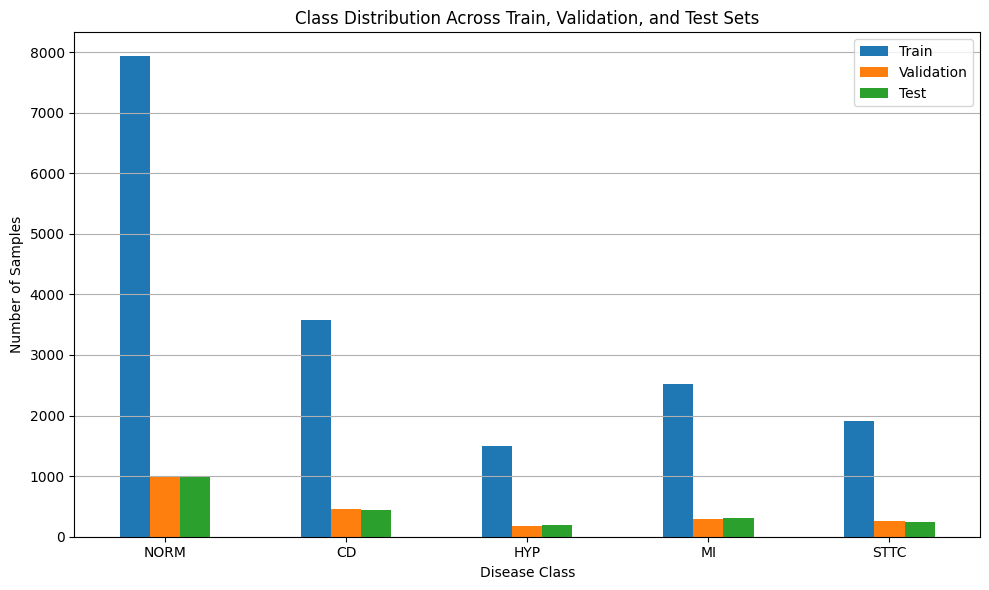

In [7]:
index_to_label = {v: k for k, v in label_map.items()}
# Convert one-hot to class labels
y_train_labels = np.argmax(y_train, axis=1)
y_val_labels = np.argmax(y_val, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

# Count class frequencies
train_counts = pd.Series(y_train_labels).value_counts().sort_index()
val_counts = pd.Series(y_val_labels).value_counts().sort_index()
test_counts = pd.Series(y_test_labels).value_counts().sort_index()

# Align the indices (classes 0–4)
all_classes = range(len(label_map))
train_counts = train_counts.reindex(all_classes, fill_value=0)
val_counts = val_counts.reindex(all_classes, fill_value=0)
test_counts = test_counts.reindex(all_classes, fill_value=0)

# Combine into DataFrame for plotting
df = pd.DataFrame({
    'Train': train_counts,
    'Validation': val_counts,
    'Test': test_counts
})
df.index = df.index.map(index_to_label)

# Plot
plt.figure(figsize=(10, 6))  # Width=10, Height=6
df.plot(kind='bar', ax=plt.gca())
plt.title("Class Distribution Across Train, Validation, and Test Sets")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

0     8000
1     1415
2      572
3       57
4      427
5      234
6      356
8       61
9     1470
10       2
11     113
12      31
13       8
14    1354
15    1298
16      48
17       5
18     273
19     104
20      52
21    1174
22     364
Name: count, dtype: int64
0     1007
1      180
2       70
3        7
4       54
5       33
6       50
8        7
9      171
10       1
11      14
12       7
14     150
15     155
16       9
17       1
18      32
19      16
20      15
21     157
22      47
Name: count, dtype: int64
0     1016
1      174
2       73
3        7
4       54
5       28
6       51
8        8
9      179
10       3
11      10
12       6
14     158
15     175
16       6
17       1
18      42
19      11
20      10
21     150
22      36
Name: count, dtype: int64


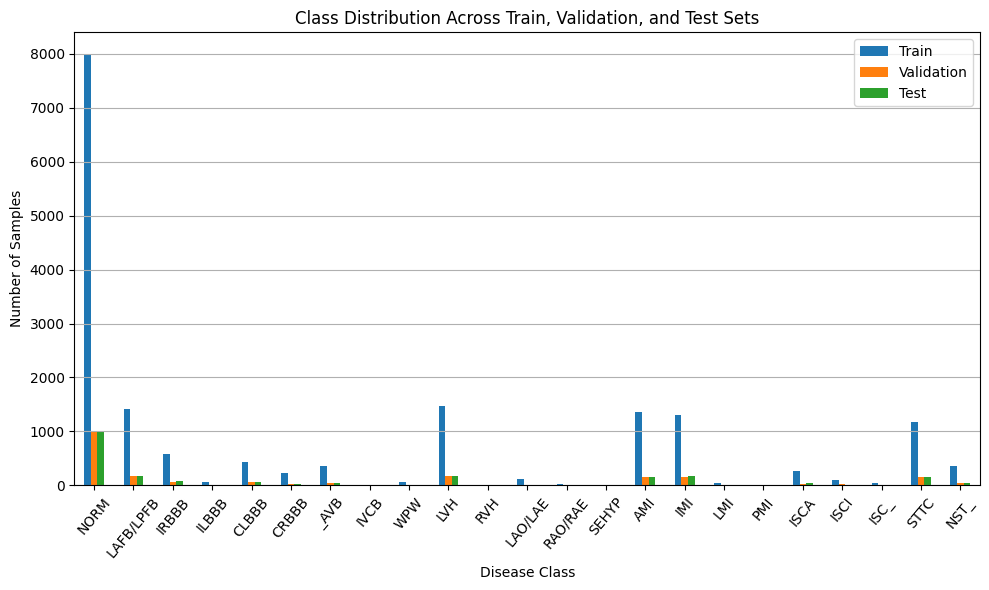

In [8]:
index_to_sub_label = {v: k for k, v in label_map_sub.items()}

# Convert one-hot to class labels
z_train_labels = np.argmax(z_train, axis=1)
z_val_labels = np.argmax(z_val, axis=1)
z_test_labels = np.argmax(z_test, axis=1)

# Count class frequencies
train_subcounts = pd.Series(z_train_labels).value_counts().sort_index()
val_subcounts = pd.Series(z_val_labels).value_counts().sort_index()
test_subcounts = pd.Series(z_test_labels).value_counts().sort_index()

print(train_subcounts)
print(val_subcounts)
print(test_subcounts)
# Align the indices (classes 0–4)
all_subclasses = range(len(label_map_sub))
train_subcounts = train_subcounts.reindex(all_subclasses, fill_value=0)
val_subcounts = val_subcounts.reindex(all_subclasses, fill_value=0)
test_subcounts = test_subcounts.reindex(all_subclasses, fill_value=0)

# Combine into DataFrame for plotting
df = pd.DataFrame({
    'Train': train_subcounts,
    'Validation': val_subcounts,
    'Test': test_subcounts
})
df.index = df.index.map(index_to_sub_label)
# Plot
plt.figure(figsize=(10, 6))  # Width=10, Height=6
df.plot(kind='bar', ax=plt.gca())
plt.title("Class Distribution Across Train, Validation, and Test Sets")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=50)
plt.grid(axis='y')
plt.tight_layout()
plt.show()